In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load our pizza data
df = pd.read_csv('pizza_orders.csv')
df['revenue'] = df['price'] * df['quantity']

print("Ready to plot!")

Ready to plot!


In [2]:
revenue_by_day = df.groupby('date')['revenue'].sum()
print(revenue_by_day)

date
Fri    513
Mon    255
Sat    360
Sun    216
Thu    381
Tue    372
Wed    156
Name: revenue, dtype: int64


In [3]:
# Define the correct day order
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

revenue_by_day = df.groupby('date')['revenue'].sum().reindex(day_order)
print(revenue_by_day)

date
Mon    255
Tue    372
Wed    156
Thu    381
Fri    513
Sat    360
Sun    216
Name: revenue, dtype: int64


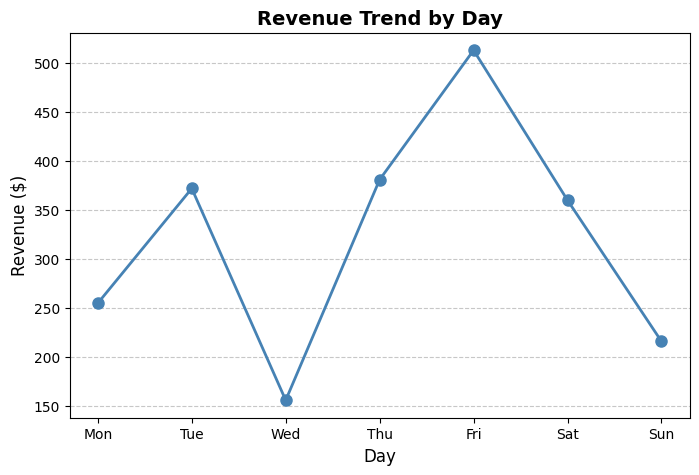

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

# Draw line
ax.plot(revenue_by_day.index, revenue_by_day.values,
        color='steelblue',
        linewidth=2,
        marker='o',
        markersize=8)

#ax.plot(revenue_by_day.index, revenue_by_day.values)

# To this
#ax.bar(revenue_by_day.index, revenue_by_day.values)

# Labels
ax.set_title('Revenue Trend by Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Revenue ($)', fontsize=12)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Is there a relationship between quantity ordered and revenue?

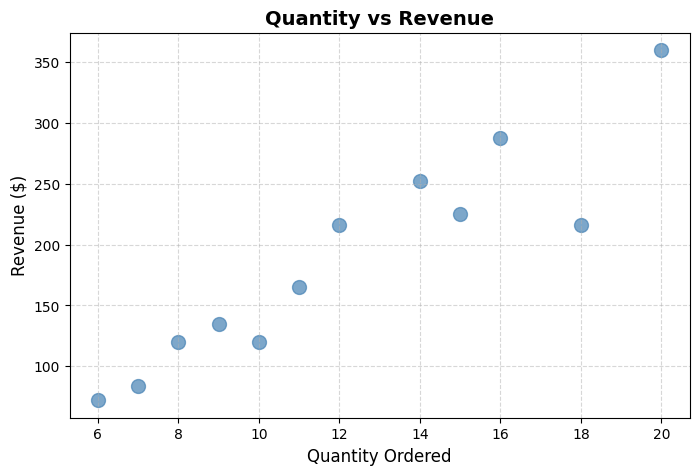

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot — quantity vs revenue
ax.scatter(df['quantity'], df['revenue'],
           color='steelblue',
           s=100,        # size of dots
           alpha=0.7)    # transparency

ax.set_title('Quantity vs Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Quantity Ordered', fontsize=12)
ax.set_ylabel('Revenue ($)', fontsize=12)

ax.grid(linestyle='--', alpha=0.5)

plt.show()

Three patterns you'll see in scatter plots:
1)Dots go up left to right ↗
2)Dots go down left to right ↘
3)Dots randomly spread 🔵🔵🔵

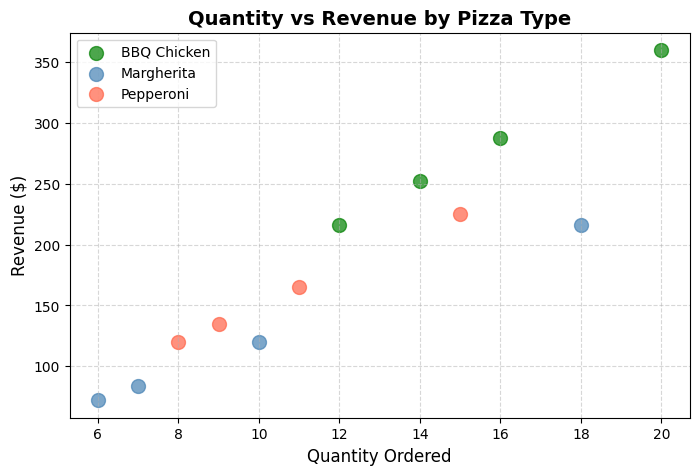

In [15]:
# Define colors for each pizza
colors = {'Margherita': 'steelblue', 
          'Pepperoni': 'tomato', 
          'BBQ Chicken': 'green'}

fig, ax = plt.subplots(figsize=(8, 5))

# Plot each pizza type separately
for pizza, group in df.groupby('pizza'):
    ax.scatter(group['quantity'], group['revenue'],
               label=pizza,
               color=colors[pizza],
               s=100,
               alpha=0.7)

ax.set_title('Quantity vs Revenue by Pizza Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Quantity Ordered', fontsize=12)
ax.set_ylabel('Revenue ($)', fontsize=12)
ax.legend()
ax.grid(linestyle='--', alpha=0.5)

plt.show()

In [19]:
for pizza, group in df.groupby('pizza'):
    #print(pizza)
    print(group)

   date        pizza  price  quantity      area  revenue
3   Thu  BBQ Chicken     18        12   Suburbs      216
5   Sat  BBQ Chicken     18        20   Suburbs      360
8   Tue  BBQ Chicken     18        14   Suburbs      252
11  Fri  BBQ Chicken     18        16  Downtown      288
  date       pizza  price  quantity      area  revenue
0  Mon  Margherita     12        10  Downtown      120
2  Wed  Margherita     12         6  Downtown       72
6  Sun  Margherita     12        18  Downtown      216
9  Wed  Margherita     12         7  Downtown       84
   date      pizza  price  quantity      area  revenue
1   Tue  Pepperoni     15         8   Suburbs      120
4   Fri  Pepperoni     15        15  Downtown      225
7   Mon  Pepperoni     15         9  Downtown      135
10  Thu  Pepperoni     15        11   Suburbs      165


What is the most common quantity ordered at our pizza shop?

In [20]:
#Plain Python way first 

# Count how many orders fall in each range
quantities = df['quantity'].values

small = 0   # 0-10
medium = 0  # 10-15
large = 0   # 15+

for q in quantities:
    if q <= 10:
        small += 1
    elif q <= 15:
        medium += 1
    else:
        large += 1

print("Small (0-10):", small)
print("Medium (10-15):", medium)
print("Large (15+):", large)

Small (0-10): 5
Medium (10-15): 4
Large (15+): 3


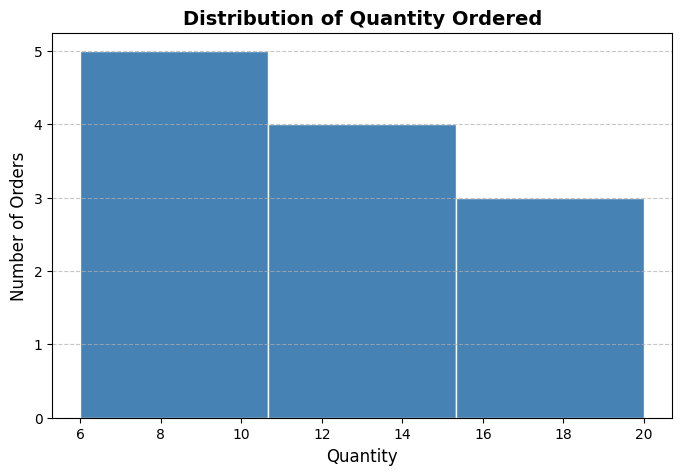

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['quantity'],
        bins=3,
        color='steelblue',
        edgecolor='white')

ax.set_title('Distribution of Quantity Ordered', fontsize=14, fontweight='bold')
ax.set_xlabel('Quantity', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Subplots: Multiple charts in one page

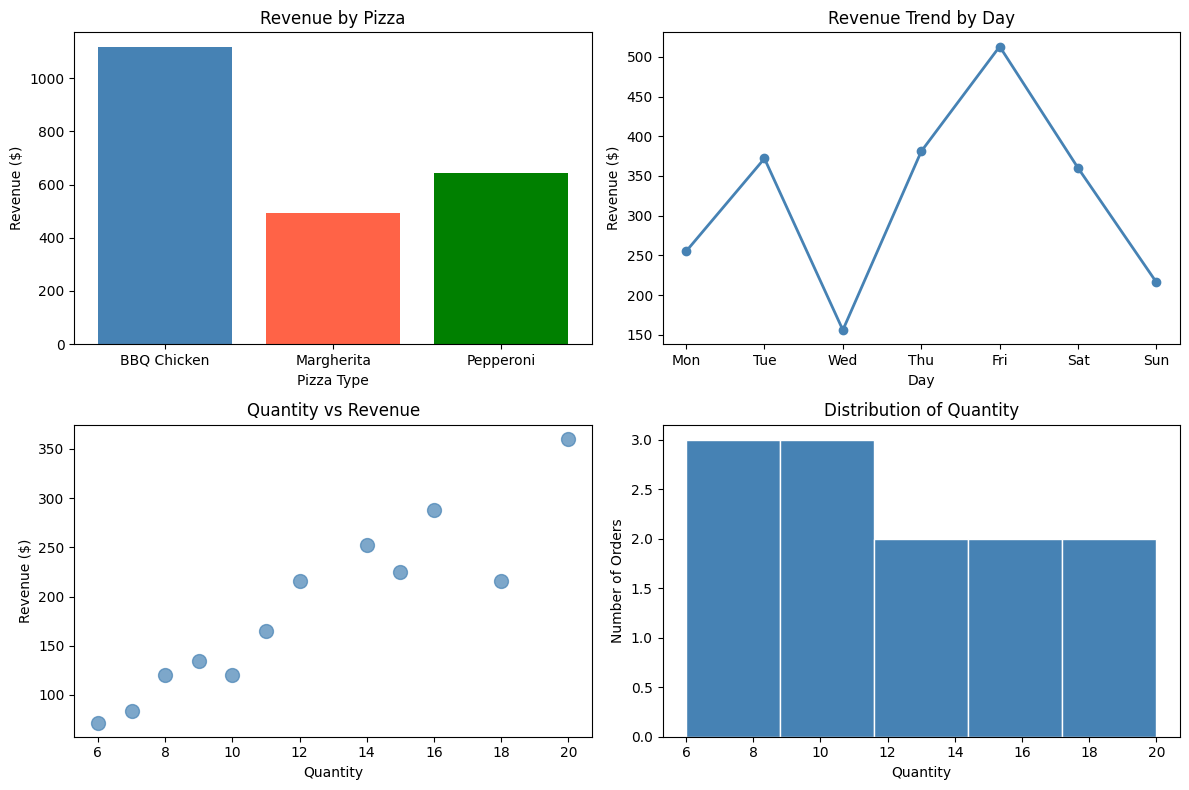

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Chart 1 — top left — Bar chart
revenue_by_pizza = df.groupby('pizza')['revenue'].sum()
axes[0,0].bar(revenue_by_pizza.index, revenue_by_pizza.values,
              color=['steelblue', 'tomato', 'green'])
axes[0,0].set_title('Revenue by Pizza')
axes[0,0].set_xlabel('Pizza Type')
axes[0,0].set_ylabel('Revenue ($)')

# Chart 2 — top right — Line chart
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
revenue_by_day = df.groupby('date')['revenue'].sum().reindex(day_order)
axes[0,1].plot(revenue_by_day.index, revenue_by_day.values,
               color='steelblue', linewidth=2, marker='o')
axes[0,1].set_title('Revenue Trend by Day')
axes[0,1].set_xlabel('Day')
axes[0,1].set_ylabel('Revenue ($)')

# Chart 3 — bottom left — Scatter plot
axes[1,0].scatter(df['quantity'], df['revenue'],
                  color='steelblue', s=100, alpha=0.7)
axes[1,0].set_title('Quantity vs Revenue')
axes[1,0].set_xlabel('Quantity')
axes[1,0].set_ylabel('Revenue ($)')

# Chart 4 — bottom right — Histogram
axes[1,1].hist(df['quantity'], bins=5,
               color='steelblue', edgecolor='white')
axes[1,1].set_title('Distribution of Quantity')
axes[1,1].set_xlabel('Quantity')
axes[1,1].set_ylabel('Number of Orders')

# Fix spacing between charts
plt.tight_layout()
fig.savefig('pizza_dashboard.png', dpi=150, bbox_inches='tight')

plt.show()